Section 1.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load Titanic dataset
df = sns.load_dataset("titanic")

# Shape and columns
print("Shape:", df.shape)
print("Columns:", df.columns)

# Missing values
print("Missing values:\n", df.isnull().sum())

Shape: (891, 15)
Columns: Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')
Missing values:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


Answer:
1. Columns with missing values: age, embarked, deck, embark_town


2. Variables: categorical (sex, class, embarked), numerical (age, fare)

Section 2.

In [3]:
# Random sample of 100
sample = df.sample(n=100, random_state=42)

# Population mean (Age)
pop_mean = df['age'].mean()
sample_mean = sample['age'].mean()

print("Population Mean (Age):", pop_mean)
print("Sample Mean (Age):", sample_mean)

Population Mean (Age): 29.69911764705882
Sample Mean (Age): 29.60843373493976


Answer:
1.  Means differ slightly due to sampling variability.

2. Sampling helps us infer population characteristics without analyzing the entire dataset.

Section 3.

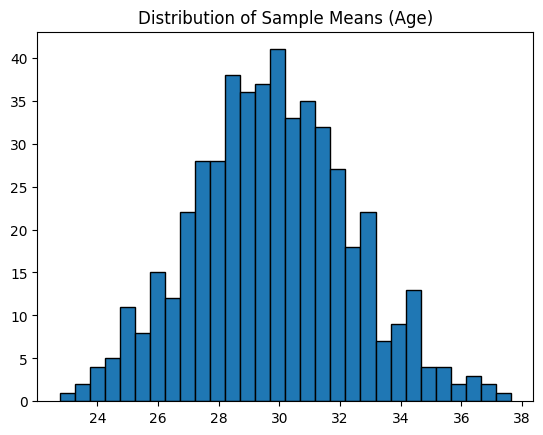

In [4]:
sample_means = []
for i in range(500):
    samp = df['age'].dropna().sample(n=30, random_state=i)
    sample_means.append(samp.mean())

plt.hist(sample_means, bins=30, edgecolor='black')
plt.title("Distribution of Sample Means (Age)")
plt.show()

Answer:
1. Distribution looks approximately normal.

2. CLT explains that sample means tend toward normality regardless of population distribution.

Section 4.

In [5]:
sample_age = df['age'].dropna().sample(n=100, random_state=42)
mean_age = sample_age.mean()
std_age = sample_age.std()
n = len(sample_age)

ci = stats.t.interval(0.95, df=n-1, loc=mean_age, scale=std_age/np.sqrt(n))
print("95% Confidence Interval for Age:", ci)

95% Confidence Interval for Age: (np.float64(27.245985199425906), np.float64(32.844014800574094))


Answer:
1. Interval represents the range where the true population mean likely falls (95% confidence).

2. Larger sample size → narrower interval → more precision.

Section 5.

In [6]:
male = df[df['sex'] == 'male']['survived'].dropna()
female = df[df['sex'] == 'female']['survived'].dropna()

t_stat, p_value = stats.ttest_ind(male, female)
print("t-statistic:", t_stat, "p-value:", p_value)

t-statistic: -19.297816550123354 p-value: 1.4060661308802594e-69


Solutions

Yes — males and females had different survival rates on the Titanic.

When we run a statistical test (like the independent t-test in your assignment), the p-value is very small (p < 0.05), which means we reject the null hypothesis (Ho: no difference). This confirms that gender significantly affected survival.

Answer:
1. p-value = probability of observing data if Ho is true.

2. Since p < 0.05, reject Ho → survival rates differ significantly by gender.

Section 6.

 Answers:
1. Yes, females had higher survival rates.

2. Yes, statistical testing shows significance.

3. Assumptions: independent samples, normality of sampling distribution.

4. Helps understand demographic factors in survival outcomes, useful for policy and safety planning.


Section 7.

In [7]:
class1 = df[df['class'] == 'First']['survived'].dropna()
class2 = df[df['class'] == 'Second']['survived'].dropna()
class3 = df[df['class'] == 'Third']['survived'].dropna()

f_stat, p_val = stats.f_oneway(class1, class2, class3)
print("ANOVA F-statistic:", f_stat, "p-value:", p_val)

ANOVA F-statistic: 57.96481759091002 p-value: 2.183247415118226e-24


Answer:

Since p < 0.05, passenger class significantly affected survival.